## $ F $ 분포
 $  F_{( df_1, df_2 )}  $
밀도, 확률, 구간, 임계치

In [1]:
# 카이제곱 분포 pdf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats   # 이렇게 하면 stats.norm(어쩌구)
from scipy.stats import norm, t, chi2, f  # 이렇게 하면 norm(어쩌구...


$ X \sim F_{(d_1, d_2)}  $ , 이때 $ X $의 밀도 at $ x $ (AI 생성).
 $$  
 f(x; d_1, d_2) = \frac{\Gamma\!\left(\dfrac{d_1+d_2}{2}\right)}{\Gamma\!\left(\dfrac{d_1}{2}\right)\Gamma\!\left(\dfrac{d_2}{2}\right)} \left(\frac{d_1}{d_2}\right)^{d_1/2} \frac{x^{\frac{d_1}{2}-1}}{\left(1+\dfrac{d_1}{d_2}x\right)^{\frac{d_1+d_2}{2}}}, \quad x > 0
 $$
$ d_1, d_2 $: 자유도. $ \Gamma $: 감마함수(난이도 높은 함수, 스킵)

특정 지점 $ x $에서 F분포 밀도는 자유도(2개)에 달렸음.

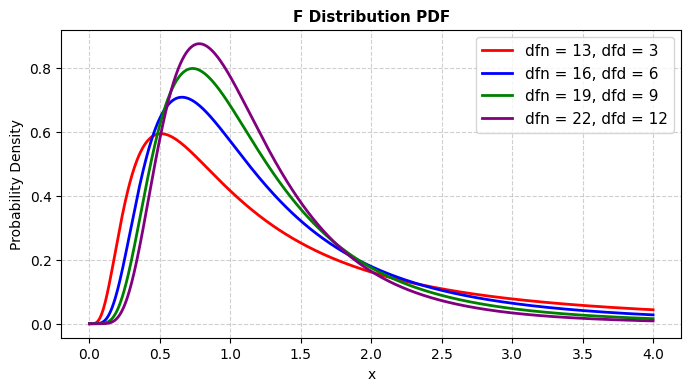

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, f

# 1. X축 범위 설정 (F 분포는 0 이상의 값만 가짐)
x = np.linspace(0, 4, 1000)

plt.figure(figsize=(8, 4))

# 2. 자유도(df)
df_1 = [13, 16, 19, 22]
df_2 = [3, 6, 9, 12]
colors = ['red', 'blue', 'green', 'purple']

# df_1, df_2, colors 리스트를 함께 반복하여 각 쌍에 대한 PDF를 플롯.
for dfn_val, dfd_val, color in zip(df_1, df_2, colors):
    # scipy.stats.f.pdf 사용: dfn과 dfd에 단일 스칼라 값 전달
    y = f.pdf(x, dfn=dfn_val, dfd=dfd_val)
    plt.plot(x, y, label=f'dfn = {dfn_val}, dfd = {dfd_val}', color=color, linewidth=2)

# 3. 그래프 스타일링
plt.title('F Distribution PDF', fontsize=11, fontweight='bold') # F-분포에 맞게 제목 수정
plt.xlabel('x', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

## $ F $ 분포 pdf에서
누적확률 $ P( X < x ) $,

유의수준에 따른 임계치, 구간 찾기 등

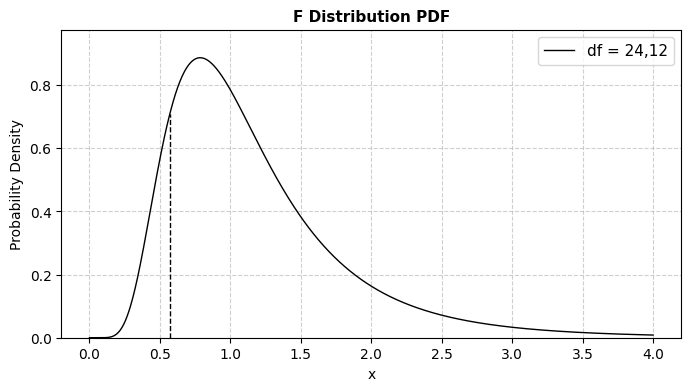

P(X <= 0.57) = 0.11656392390320004
0.95 확률 구간: 0.393522947086408 3.0187111626190046


In [10]:
# 1. X축 범위 설정 (카이제곱 분포는 0 이상의 값만 가짐)
df_1 = 24
df_2 = 12
x = np.linspace(0, 4, 1000)
y = f.pdf(x, dfn=df_1, dfd=df_2)

x_ref = 0.57                                         # x축 경계, 참고용.
x_look = [x_ref, x_ref]                             # 경계선 표시용.
y_look = [0, f.pdf(x_look[1], dfn=df_1, dfd=df_2) ] # -ditto -
y_max = max(y)*1.1                                  # y축 보기 좋게 제한 용도

plt.figure(figsize=(8, 4))
plt.plot(x, y, label=f'df = {df_1},{df_2}', color='black', linewidth=1)
plt.plot(x_look, y_look, linestyle='--', lw=1, color='black' )  # 경계선, 점선

plt.title('F Distribution PDF', fontsize=11, fontweight='bold')
plt.xlabel('x', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.ylim(0, y_max)                                  # Y축 레이블 범위를 보기 좋게 제한
plt.grid(True, linestyle='--',  alpha=0.6)
plt.legend(fontsize=11)
plt.show()

x_below = x_look[1]                        # 여기까지 누적확률 계산 지점.
prob = f.cdf(x_below, dfn=df_1, dfd=df_2)
print(f"P(X <= {x_below}) = {prob}" )

sig_lvl = 0.05                             # 유의수준, 신뢰수준,
cnf_lvl = 1-sig_lvl
cv_lft = f.ppf( sig_lvl / 2 , dfn=df_1, dfd=df_2)
cv_rgt = f.ppf( 1- sig_lvl / 2, dfn=df_1, dfd=df_2)
print(f"{cnf_lvl} 확률 구간:", cv_lft, cv_rgt)
